In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from datasets import Dataset as HFDataset

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    DebertaV2TokenizerFast,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    get_linear_schedule_with_warmup,
)

import random
import zipfile
import os
import re

# Setting Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()
print(f'Using device: {DEVICE}  |  GPUs available: {N_GPUS}')

# Extracting the data
DATASET_PATH = "/kaggle/input/datasets/rohitkumarkhajekar/nlp-dataset/propaganda_dataset_v2"
EXTRACT_DIR = "/kaggle/working/"
MAX_LENGTH = 128
BATCH_SIZE = 8
EPOCHS = 5

print(os.listdir(DATASET_PATH))

Using device: cuda  |  GPUs available: 2
['propaganda_val.tsv', 'propaganda_train.tsv']


In [2]:
train_file = None
val_file = None

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        full_path = os.path.join(root, file)
        filename = file.lower()
        if "train" in filename and filename.endswith(".tsv"):
            train_file = full_path
        elif (
            ("val" in filename or "validation" in filename)
            and filename.endswith(".tsv")
        ):
            val_file = full_path

print("Train File:", train_file)
print("Test File:", val_file)

# Loading Data
train_df = pd.read_csv(train_file, sep="\t")
val_df = pd.read_csv(val_file, sep="\t")

print("\nTrain Shape:", train_df.shape)
print("Test Shape:", val_df.shape)

print("\nColumns:")
print(train_df.columns)

print("\nSample Rows:")
print(train_df.head())

Train File: /kaggle/input/datasets/rohitkumarkhajekar/nlp-dataset/propaganda_dataset_v2/propaganda_train.tsv
Test File: /kaggle/input/datasets/rohitkumarkhajekar/nlp-dataset/propaganda_dataset_v2/propaganda_val.tsv

Train Shape: (2414, 2)
Test Shape: (580, 2)

Columns:
Index(['label', 'tagged_in_context'], dtype='object')

Sample Rows:
            label                                  tagged_in_context
0  not_propaganda         No, <BOS> he <EOS> will not be confirmed. 
1  not_propaganda  This declassification effort <BOS> won’t make ...
2     flag_waving  The Obama administration misled the <BOS> Amer...
3  not_propaganda  “It looks like we’re capturing the demise of t...
4  not_propaganda           <BOS> Location: Westerville, Ohio <EOS> 


In [3]:
# Checking the Label
print("Train Label Distribution:\n")
print(train_df["label"].value_counts())

# Cleaning
def clean_text(text):
    text = str(text)
    text = text.replace("<BOS>", "")
    text = text.replace("<EOS>", "")
    text = text.strip()

    return text


def extract_span(text):
    pattern = r"<BOS>(.*?)<EOS>"
    match = re.search(pattern, text)
    if match:
        return match.group(1).strip()

    return ""

# Preprocessing
train_df["clean_text"] = train_df["tagged_in_context"].apply(clean_text)
val_df["clean_text"] = val_df["tagged_in_context"].apply(clean_text)
train_df["span"] = train_df["tagged_in_context"].apply(extract_span)
val_df["span"] = val_df["tagged_in_context"].apply(extract_span)

print("\nProcessed Examples:\n")
print(
    train_df[
        [
            "label",
            "tagged_in_context",
            "span",
            "clean_text"
        ]
    ].head()
)

Train Label Distribution:

label
not_propaganda               1191
exaggeration,minimisation     164
causal_oversimplification     158
name_calling,labeling         157
loaded_language               154
appeal_to_fear_prejudice      151
flag_waving                   148
repetition                    147
doubt                         144
Name: count, dtype: int64

Processed Examples:

            label                                  tagged_in_context  \
0  not_propaganda         No, <BOS> he <EOS> will not be confirmed.    
1  not_propaganda  This declassification effort <BOS> won’t make ...   
2     flag_waving  The Obama administration misled the <BOS> Amer...   
3  not_propaganda  “It looks like we’re capturing the demise of t...   
4  not_propaganda           <BOS> Location: Westerville, Ohio <EOS>    

                                                span  \
0                                                 he   
1  won’t make things any worse than they are for ...   
2           

1. Task 1: Propaganda Technique Classification
   - TF-IDF + Logistic Regression
   - BERT-based classifier

In [4]:
# Removing non-propaganda samples
prop_train = train_df[
    train_df["label"] != "not propaganda"
].copy()

prop_val = val_df[
    val_df["label"] != "not propaganda"
].copy()

prop_train = train_df[
    ~train_df["label"].str.contains("not", case=False)
].copy()

prop_val = val_df[
    ~val_df["label"].str.contains("not", case=False)
].copy()

print(prop_train["label"].unique())
print(prop_val["label"].unique())

['flag_waving' 'loaded_language' 'doubt' 'name_calling,labeling'
 'appeal_to_fear_prejudice' 'repetition' 'causal_oversimplification'
 'exaggeration,minimisation']
['causal_oversimplification' 'appeal_to_fear_prejudice' 'repetition'
 'name_calling,labeling' 'loaded_language' 'flag_waving' 'doubt'
 'exaggeration,minimisation']


TF-IDF + Logistic Regression


TF-IDF RESULTS
Macro F1 Score: 0.38144628317583396

Classification Report:

                           precision    recall  f1-score   support

 appeal_to_fear_prejudice       0.39      0.42      0.40        43
causal_oversimplification       0.27      0.32      0.29        31
                    doubt       0.40      0.50      0.45        38
exaggeration,minimisation       0.30      0.29      0.29        28
              flag_waving       0.66      0.59      0.62        39
          loaded_language       0.34      0.46      0.39        37
    name_calling,labeling       0.33      0.23      0.27        31
               repetition       0.50      0.25      0.33        32

                 accuracy                           0.39       279
                macro avg       0.40      0.38      0.38       279
             weighted avg       0.41      0.39      0.39       279



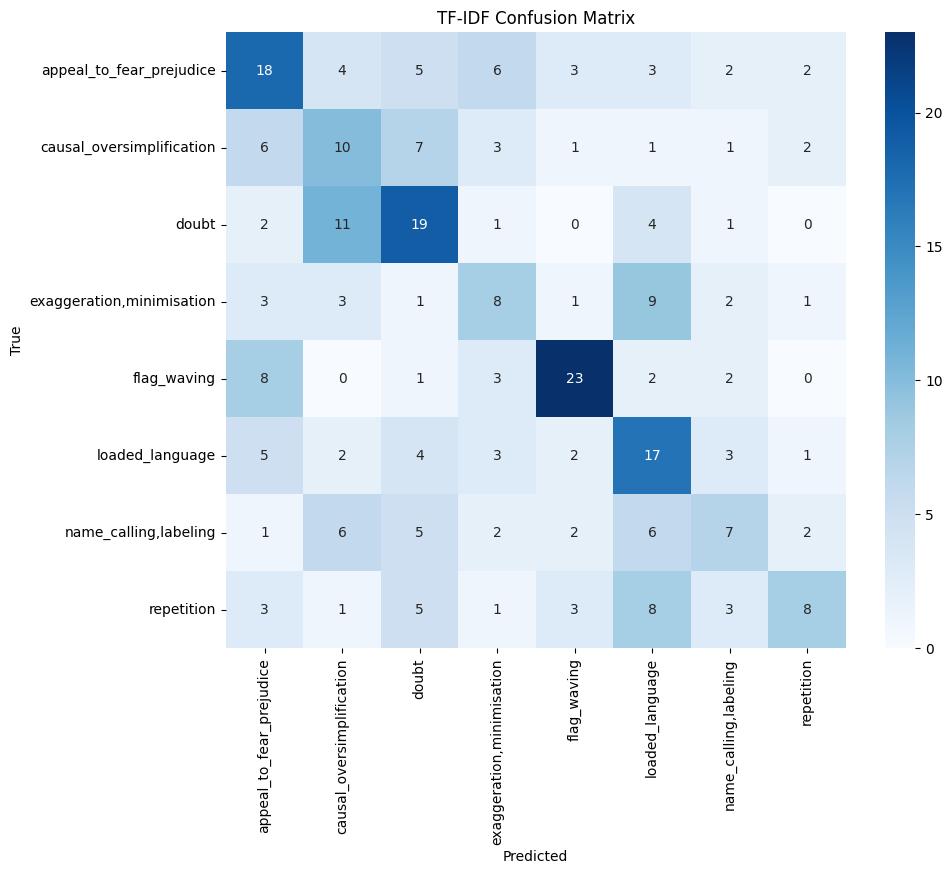

In [5]:
# Task 1A - TF-IDF + Logistic Regression
tfidf_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=10000,
            ngram_range=(1, 2),
            stop_words="english"
        )
    ),

    (
        "clf",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

# Traning and predicting
tfidf_pipeline.fit(
    prop_train["span"],
    prop_train["label"]
)

tfidf_preds = tfidf_pipeline.predict(
    prop_val["span"]
)

# Evaluating
tfidf_macro_f1 = f1_score(
    prop_val["label"],
    tfidf_preds,
    average="macro"
)

print("\nTF-IDF RESULTS")
print("Macro F1 Score:", tfidf_macro_f1)

print("\nClassification Report:\n")

print(
    classification_report(
        prop_val["label"],
        tfidf_preds
    )
)

# Confusion Matrix
cm = confusion_matrix(
    prop_val["label"],
    tfidf_preds,
    labels=sorted(prop_val["label"].unique())
)
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(prop_val["label"].unique()),
    yticklabels=sorted(prop_val["label"].unique())
)

plt.title("TF-IDF Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.show()

DistilBERT Classification

In [6]:
# Removing missing spans
prop_train = prop_train.dropna(subset=["span"])
prop_val = prop_val.dropna(subset=["span"])

# Converting to string
prop_train["span"] = prop_train["span"].astype(str)
prop_val["span"] = prop_val["span"].astype(str)

# Reset index
prop_train = prop_train.reset_index(drop=True)
prop_val = prop_val.reset_index(drop=True)

print(prop_train["span"].head())

0                                      American people
1                                          annihilated
2                                   so-called evidence
3                                      hateful conduct
4    point to Iran’s positioning itself for more ag...
Name: span, dtype: object


In [8]:
# Task 1B - DistilBERT Classification
MODEL_NAME = "distilbert-base-uncased"

# Encoding the label
labels = sorted(prop_train["label"].unique())
label2id = {
    label: idx
    for idx, label in enumerate(labels)
}
id2label = {
    idx: label
    for label, idx in label2id.items()
}
prop_train["label_id"] = prop_train["label"].map(label2id)
prop_val["label_id"] = prop_val["label"].map(label2id)
print("Label Mapping:")
print(label2id)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)
# Dataset Class
class PropagandaDataset:
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.texts = dataframe["span"].tolist()
        self.labels = dataframe["label_id"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids":
                encoding["input_ids"].squeeze(0),
            "attention_mask":
                encoding["attention_mask"].squeeze(0),
            "labels":
                torch.tensor(label, dtype=torch.long)
        }
        
# Dataset
train_dataset = PropagandaDataset(
    prop_train,
    tokenizer
)
val_dataset = PropagandaDataset(
    prop_val,
    tokenizer
)

# Data Loader
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=8
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels)
)
model.to(DEVICE)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5
)

# Scheduler
EPOCHS = 5
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# Training Loop
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels_batch = batch["labels"].to(DEVICE)
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels_batch
        )
        loss = outputs.loss

        if torch.isnan(loss):
            continue
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print("Training Loss:", avg_loss)

# Evaluation
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels_batch = batch["labels"].to(DEVICE)
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(
            preds.cpu().numpy()
        )
        all_labels.extend(
            labels_batch.cpu().numpy()
        )

#  Calculating macro f1
macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print("\nDISTILBERT RESULTS")
print("Macro F1 Score:", macro_f1)

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=labels,
        zero_division=0
    )
)


Label Mapping:
{'appeal_to_fear_prejudice': 0, 'causal_oversimplification': 1, 'doubt': 2, 'exaggeration,minimisation': 3, 'flag_waving': 4, 'loaded_language': 5, 'name_calling,labeling': 6, 'repetition': 7}


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/5
Training Loss: 1.981607621791316

Epoch 2/5
Training Loss: 1.641183941972022

Epoch 3/5
Training Loss: 1.3761062364952237

Epoch 4/5
Training Loss: 1.2034592570043077

Epoch 5/5
Training Loss: 1.1106544507095237

DISTILBERT RESULTS
Macro F1 Score: 0.5375976923577543

Classification Report:

                           precision    recall  f1-score   support

 appeal_to_fear_prejudice       0.55      0.60      0.58        43
causal_oversimplification       0.42      0.58      0.49        31
                    doubt       0.67      0.47      0.55        38
exaggeration,minimisation       0.38      0.39      0.39        28
              flag_waving       0.72      0.72      0.72        39
          loaded_language       0.59      0.59      0.59        37
    name_calling,labeling       0.62      0.74      0.68        31
               repetition       0.40      0.25      0.31        32

                 accuracy                           0.55       279
                macro avg

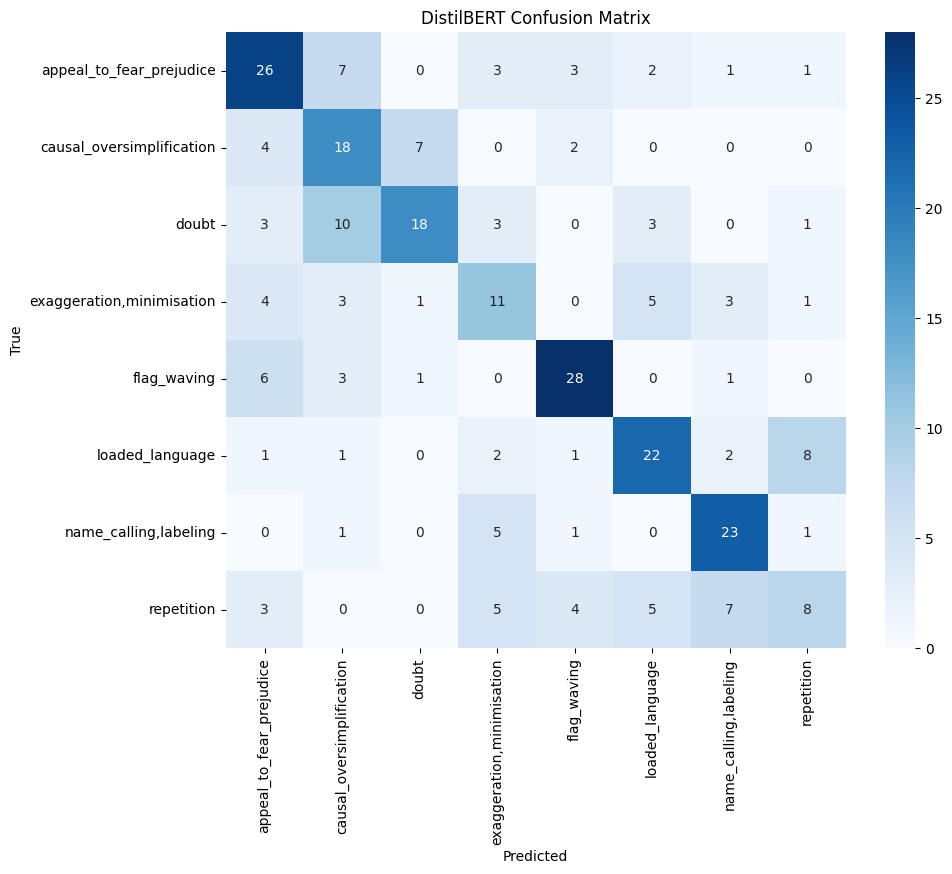

                   Technique  TF-IDF_F1  DistilBERT_F1
0   appeal_to_fear_prejudice      0.404          0.578
1  causal_oversimplification      0.294          0.486
2                      doubt      0.447          0.554
3  exaggeration,minimisation      0.291          0.386
4                flag_waving      0.622          0.718
5            loaded_language      0.391          0.595
6      name_calling,labeling      0.269          0.676
7                 repetition      0.333          0.308
                          Model  Macro_F1
0  TF-IDF + Logistic Regression  0.381446
1                    DistilBERT  0.537598


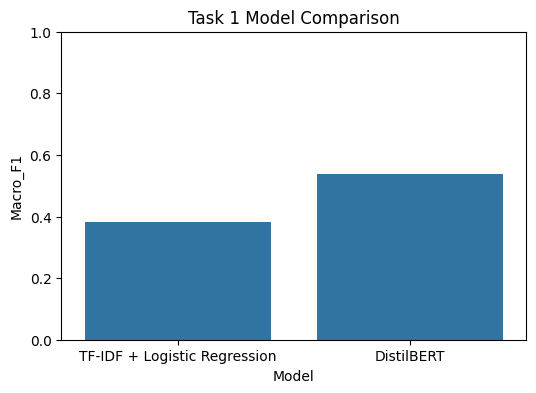

In [9]:
distilbert_cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    distilbert_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(rotation=90)

plt.show()

# TF-IDF report
tfidf_report = classification_report(
    prop_val["label"],
    tfidf_preds,
    output_dict=True,
    zero_division=0
)

# DistilBERT report
distilbert_report = classification_report(
    all_labels,
    all_preds,
    target_names=labels,
    output_dict=True,
    zero_division=0
)

# Build comparison table
comparison_rows = []

for label in labels:
    comparison_rows.append({
        "Technique": label,
        "TF-IDF_F1": round(tfidf_report[label]["f1-score"], 3),
        "DistilBERT_F1": round(distilbert_report[label]["f1-score"], 3)
    })

comparison_df = pd.DataFrame(comparison_rows)

print(comparison_df)

results_df = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "DistilBERT"
    ],
    "Macro_F1": [
        tfidf_macro_f1,
        macro_f1
    ]
})

print(results_df)
plt.figure(figsize=(6,4))

sns.barplot(
    data=results_df,
    x="Model",
    y="Macro_F1"
)
plt.title("Task 1 Model Comparison")
plt.ylim(0, 1)
plt.show()

In [10]:
## TASK 2A — PIPELINE ARCHITECTURE - BINARY SENTENCE CLASSIFIER - BIO TOKEN TAGGER
# Binary labelling
train_df["binary_label"] = train_df["label"].apply(
    lambda x: 0 if x == "not_propaganda" else 1
)

val_df["binary_label"] = val_df["label"].apply(
    lambda x: 0 if x == "not_propaganda" else 1
)
print(train_df["binary_label"].value_counts())
# Binary sentence classifier → BIO token tagger (BERT-CRF)
binary_pipeline = Pipeline([
    (
        "tfidf",

        TfidfVectorizer(
            max_features=10000,
            ngram_range=(1,2),
            stop_words="english"
        )
    ),

    (
        "clf",

        LogisticRegression(
            max_iter=1000
        )
    )
])

binary_pipeline.fit(
    train_df["clean_text"],
    train_df["binary_label"]
)

binary_preds = binary_pipeline.predict(
    val_df["clean_text"]
)

binary_f1 = f1_score(
    val_df["binary_label"],
    binary_preds
)

print("\nBinary Classification F1:", binary_f1)

binary_label
1    1223
0    1191
Name: count, dtype: int64

Binary Classification F1: 0.6790540540540541


In [11]:
# TASK 2B — DIRECT DISTILBERT TOKEN CLASSIFICATION
# Creating Bio Labels
def create_bio_labels(text, span, technique):
    words = text.split()
    span_words = span.split()
    labels = ["O"] * len(words)

    if len(span_words) == 0:
        return words, labels
    for i in range(len(words)):
        if words[i:i+len(span_words)] == span_words:
            labels[i] = f"B-{technique}"
            for j in range(1, len(span_words)):
                if i + j < len(labels):
                    labels[i+j] = f"I-{technique}"

            break
    return words, labels
    
# Building the Bio Data 
train_bio = []
for _, row in prop_train.iterrows():
    words, labels_seq = create_bio_labels(
        row["clean_text"],
        row["span"],
        row["label"]
    )
    
    train_bio.append(
        (words, labels_seq)
    )

val_bio = []
for _, row in prop_val.iterrows():
    words, labels_seq = create_bio_labels(
        row["clean_text"],
        row["span"],
        row["label"]
    )

    val_bio.append(
        (words, labels_seq)
    )

print("\nSample BIO Example:\n")
print(train_bio[0])

unique_tags = {"O"}
for label in prop_train["label"].unique():
    unique_tags.add(f"B-{label}")
    unique_tags.add(f"I-{label}")

tag2id = {
    tag: idx
    for idx, tag in enumerate(sorted(unique_tags))
}

id2tag = {
    idx: tag
    for tag, idx in tag2id.items()
}

print(tag2id)

# Tokenizer
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

# Token Classification Dataset
class TokenClassificationDataset:
    def __init__(self, bio_records, tokenizer, max_len=256):
        self.records = bio_records
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        words, labels = self.records[idx]
        encoding = self.tokenizer(
            words,
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        word_ids = encoding.word_ids(batch_index=0)
        aligned_labels = []
        previous_word_idx = None
        for word_idx in word_ids:
            if word_idx is None:
                aligned_labels.append(-100)
            elif word_idx != previous_word_idx:
                aligned_labels.append(
                    tag2id[labels[word_idx]]
                )

            else:
                current_label = labels[word_idx]
                if current_label.startswith("B-"):
                    current_label = current_label.replace(
                        "B-",
                        "I-"
                    )
                    
                aligned_labels.append(
                    tag2id[current_label]
                )

            previous_word_idx = word_idx

        return {
            "input_ids":
                encoding["input_ids"].squeeze(0),
            "attention_mask":
                encoding["attention_mask"].squeeze(0),
            "labels":
                torch.tensor(
                    aligned_labels,
                    dtype=torch.long
                )
        }

# Dataset
train_token_dataset = TokenClassificationDataset(
    train_bio,
    tokenizer
)

val_token_dataset = TokenClassificationDataset(
    val_bio,
    tokenizer
)

train_token_loader = DataLoader(
    train_token_dataset,
    batch_size=4,
    shuffle=True
)

val_token_loader = DataLoader(
    val_token_dataset,
    batch_size=4
)

# Token Classification model
token_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(tag2id)
)

token_model.to(DEVICE)

optimizer = torch.optim.AdamW(
    token_model.parameters(),
    lr=1e-5
)

# TRAINING LOOP
EPOCHS = 5
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    token_model.train()
    
    total_loss = 0

    for batch in train_token_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels_batch = batch["labels"].to(DEVICE)

        outputs = token_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels_batch
        )
        loss = outputs.loss

        if torch.isnan(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            token_model.parameters(),
            max_norm=1.0
        )
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_token_loader)

    print("Training Loss:", avg_loss)


Sample BIO Example:

(['The', 'Obama', 'administration', 'misled', 'the', 'American', 'people', 'and', 'Congress', 'because', 'they', 'were', 'desperate', 'to', 'get', 'a', 'deal', 'with', 'Iran,', 'said', 'Sen.'], ['O', 'O', 'O', 'O', 'O', 'B-flag_waving', 'I-flag_waving', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'])
{'B-appeal_to_fear_prejudice': 0, 'B-causal_oversimplification': 1, 'B-doubt': 2, 'B-exaggeration,minimisation': 3, 'B-flag_waving': 4, 'B-loaded_language': 5, 'B-name_calling,labeling': 6, 'B-repetition': 7, 'I-appeal_to_fear_prejudice': 8, 'I-causal_oversimplification': 9, 'I-doubt': 10, 'I-exaggeration,minimisation': 11, 'I-flag_waving': 12, 'I-loaded_language': 13, 'I-name_calling,labeling': 14, 'I-repetition': 15, 'O': 16}


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/5
Training Loss: 1.4993473429695454

Epoch 2/5
Training Loss: 1.2447567755490347

Epoch 3/5
Training Loss: 1.066076367314345

Epoch 4/5
Training Loss: 0.8405346161886758

Epoch 5/5
Training Loss: 0.6915034229556719


In [12]:
!pip install seqeval -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [13]:
from seqeval.metrics import (
    f1_score as seq_f1,
    classification_report as seq_report
)

# Token Classification
token_model.eval()
true_predictions = []
true_labels = []

with torch.no_grad():
    for batch in val_token_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels_batch = batch["labels"].to(DEVICE)
        
        outputs = token_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        predictions = torch.argmax(
            logits,
            dim=2
        )

        predictions = predictions.cpu().numpy()
        labels_np = labels_batch.cpu().numpy()

        # Removing padding Tokens
        for pred, lab in zip(predictions, labels_np):
            true_pred = []
            true_lab = []

            for p, l in zip(pred, lab):
                if l != -100:
                    true_pred.append(
                        id2tag[p]
                    )

                    true_lab.append(
                        id2tag[l]
                    )

            true_predictions.append(true_pred)
            true_labels.append(true_lab)

# Seqeval Metrics
span_f1 = seq_f1(
    true_labels,
    true_predictions
)

print("TOKEN CLASSIFICATION RESULTS")
print("Span-Level F1 Score:", span_f1)
print("Detailed Report:")

print(
    seq_report(
        true_labels,
        true_predictions
    )
)

TOKEN CLASSIFICATION RESULTS
Span-Level F1 Score: 0.030050083472454095
Detailed Report:
                           precision    recall  f1-score   support

 appeal_to_fear_prejudice       0.04      0.05      0.04        43
causal_oversimplification       0.03      0.03      0.03        31
                    doubt       0.00      0.00      0.00        38
exaggeration,minimisation       0.02      0.04      0.03        28
              flag_waving       0.04      0.10      0.06        39
          loaded_language       0.25      0.03      0.05        37
    name_calling,labeling       0.00      0.00      0.00        31
               repetition       0.00      0.00      0.00        32

                micro avg       0.03      0.03      0.03       279
                macro avg       0.05      0.03      0.03       279
             weighted avg       0.05      0.03      0.03       279



/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


TOKENS:

['Mostly', 'because', 'the', 'country', 'would', 'not', 'last', 'long', 'without', 'an', 'outside', 'high', 'IQ', 'elite', 'to', 'run', 'the', 'country', '.']

TRUE LABELS:

['O', 'O', 'B-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'I-causal_oversimplification', 'O']

PREDICTED LABELS:

['O', 'O', 'O', 'I-flag_waving', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'I-flag_waving', 'O']
TOKENS:

['Lyndon', 'Johnson', 'gets', 'Earl', 'Warren', 'and', 'Sen.', 'Richard', 'Russel', 'to', 'join', 'the', 'Warren', 'Commission', 'by', 'telling', 'them', 't

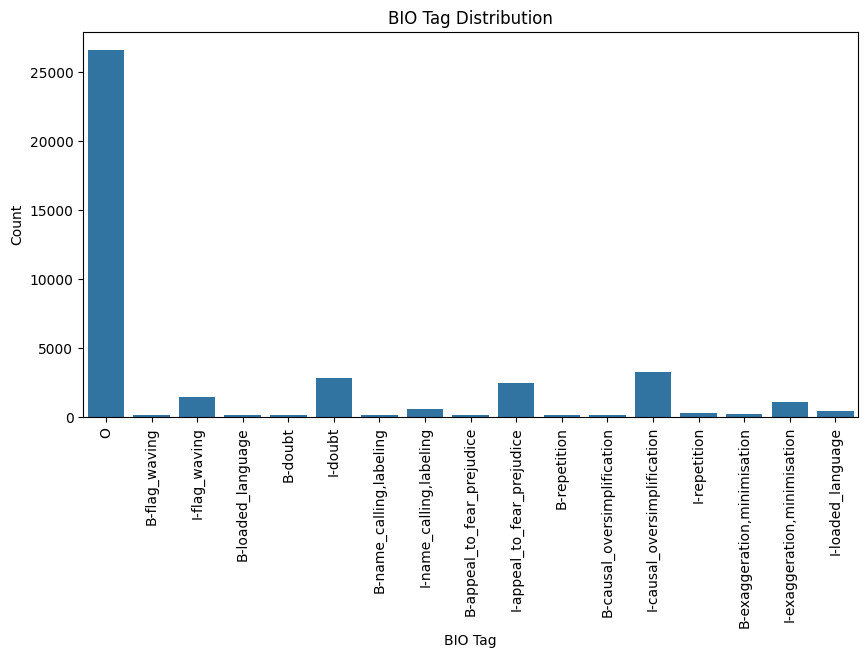

In [14]:
# Sample Prediction
for i in range(3):

    print("TOKENS:\n")
    print(val_bio[i][0])

    print("\nTRUE LABELS:\n")
    print(true_labels[i])

    print("\nPREDICTED LABELS:\n")
    print(true_predictions[i])

from collections import Counter

tag_counter = Counter()

for _, labels_seq in train_bio:
    tag_counter.update(labels_seq)

bio_df = pd.DataFrame({
    "BIO_Tag": list(tag_counter.keys()),
    "Count": list(tag_counter.values())
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=bio_df,
    x="BIO_Tag",
    y="Count"
)

plt.title("BIO Tag Distribution")
plt.xlabel("BIO Tag")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

In [15]:
# HIGHLIGHT PREDICTION ERRORS
example_idx = 0
tokens = val_bio[example_idx][0]
true_tags = true_labels[example_idx]
pred_tags = true_predictions[example_idx]
comparison = []

for token, true_tag, pred_tag in zip(
    tokens,
    true_tags,
    pred_tags
):

    comparison.append({
        "Token": token,
        "True_Label": true_tag,
        "Predicted_Label": pred_tag,
        "Correct":
            "✓" if true_tag == pred_tag else "✗"
    })

comparison_df = pd.DataFrame(comparison)

print(comparison_df)


      Token                   True_Label Predicted_Label Correct
0    Mostly                            O               O       ✓
1   because                            O               O       ✓
2       the  B-causal_oversimplification               O       ✗
3   country  I-causal_oversimplification   I-flag_waving       ✗
4     would  I-causal_oversimplification               O       ✗
5       not  I-causal_oversimplification               O       ✗
6      last  I-causal_oversimplification               O       ✗
7      long  I-causal_oversimplification               O       ✗
8   without  I-causal_oversimplification               O       ✗
9        an  I-causal_oversimplification               O       ✗
10  outside  I-causal_oversimplification               O       ✗
11     high  I-causal_oversimplification               O       ✗
12       IQ  I-causal_oversimplification               O       ✗
13    elite  I-causal_oversimplification               O       ✗
14       to  I-causal_ove

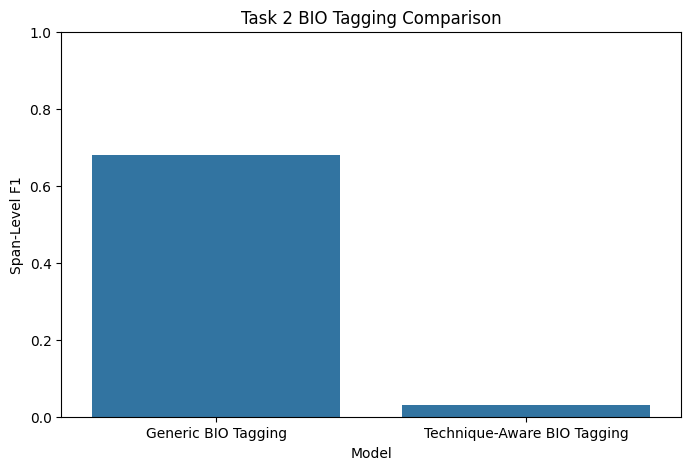

In [16]:
generic_span_f1 = binary_f1
technique_span_f1 = span_f1

bio_results = pd.DataFrame({

    "Model": [
        "Generic BIO Tagging",
        "Technique-Aware BIO Tagging"
    ],

    "Span_F1": [
        generic_span_f1,
        technique_span_f1
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=bio_results,
    x="Model",
    y="Span_F1"
)

plt.title("Task 2 BIO Tagging Comparison")

plt.ylabel("Span-Level F1")

plt.ylim(0, 1)

plt.show()


Epoch 1/5
Training Loss: 1.1014395843144336

Epoch 2/5
Training Loss: 1.086808809657502

Epoch 3/5
Training Loss: 1.092856439889646

Epoch 4/5
Training Loss: 1.088463183321984

Epoch 5/5
Training Loss: 1.0941096945525774


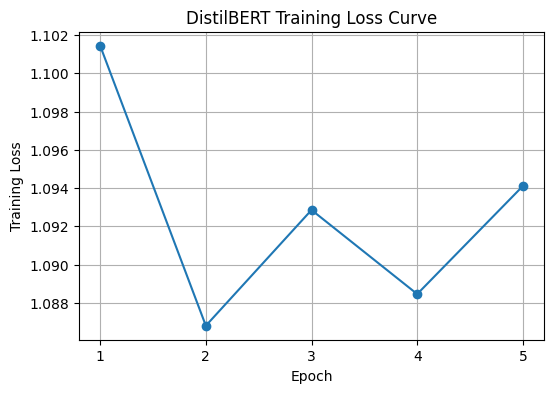

In [17]:
# Store training losses
train_losses = []

# TRAINING LOOP
EPOCHS = 5

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels_batch = batch["labels"].to(DEVICE)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels_batch
        )

        loss = outputs.loss

        if torch.isnan(loss):
            continue

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Save loss
    train_losses.append(avg_loss)

    print("Training Loss:", avg_loss)

# Plot Training Loss Curve
plt.figure(figsize=(6,4))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker='o'
)

plt.title("DistilBERT Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.xticks(range(1, EPOCHS + 1))

plt.grid(True)

plt.show()